## Imbalanced datasets
In this notebook, we will explore how to handle imbalanced datasets. An imbalanced dataset is one where the classes are not represented equally. For example, in a binary classification problem, one class may have significantly more samples than the other class. This can lead to biased models that perform well on the majority class but poorly on the minority class.

In [8]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [9]:
n_class_0, n_class_1

(900, 100)

### Create a dataframe with imbalanced classes

In [10]:
class_0 = pd.DataFrame({
    'feature1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})
class_1 = pd.DataFrame({
    'feature1': np.random.normal(loc=1, scale=1, size=n_class_1),
    'feature2': np.random.normal(loc=1, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [11]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)

In [12]:
df.head()

,feature1,feature2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [13]:
df.tail()

,feature1,feature2,target
995,0.376371,1.845701,1
996,1.239810,-0.119923,1
997,0.131760,0.640703,1
998,1.902006,-0.609695,1
999,1.697490,1.013570,1


In [14]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

### Upsampling the minority class
Upsampling is a technique where we increase the number of samples in the minority class by randomly duplicating samples from that class. This can help balance the dataset and improve model performance on the minority class.

In [15]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [16]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [17]:
df_minority_upsampled.shape

(900, 3)

In [18]:
df_minority_upsampled.head

<bound method NDFrame.head of      feature1  feature2  target
951  0.125854  0.843917       1
992  1.196570  0.397425       1
914  0.932170  1.998053       1
971  1.272825  2.034197       1
960  1.870056  0.550485       1
..        ...       ...     ...
952  0.188902  1.189189       1
965  2.919526  0.980541       1
976  1.810326  2.604614       1
942  2.621531  1.168229       1
974  0.160887  1.489203       1

[900 rows x 3 columns]>

In [19]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [20]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

### Downsampling the majority class
Downsampling is a technique where we decrease the number of samples in the majority class by randomly removing samples from that class. This can also help balance the dataset and improve model performance on the minority class.

### CAUTION: Upsampling and downsampling can lead to overfitting and loss of information, respectively. It is important to evaluate the performance of the model on a separate test set to ensure that it generalizes well to unseen data.

In [21]:
class_0 = pd.DataFrame({
    'feature1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})
class_1 = pd.DataFrame({
    'feature1': np.random.normal(loc=1, scale=1, size=n_class_1),
    'feature2': np.random.normal(loc=1, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [22]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [23]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)

In [24]:
df_majority_downsampled.shape

(100, 3)

In [25]:
df_downsampled = pd.concat([df_minority, df_majority_downsampled])

In [26]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

## SMOTE (Synthetic Minority Over-sampling Technique)
SMOTE is a more sophisticated technique for handling imbalanced datasets. It works by creating synthetic samples of the minority class by interpolating between existing samples. This can help improve model performance on the minority class without the risk of overfitting that comes with simple upsampling.

In [27]:
from sklearn.datasets import make_classification

In [28]:
X, y = make_classification(n_samples=1000, n_redundant=0, n_features=2, n_informative=1, n_clusters_per_class=1, weights=[0.9], random_state=12)

In [29]:
df1 = pd.DataFrame(X, columns=['feature1', 'feature2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)
final_df.head()

,feature1,feature2,target
0,-0.299825,-1.246155,0
1,-1.732630,-1.137781,0
2,-0.777205,0.877347,0
3,-1.907006,-0.556702,0
4,-1.856717,-0.362128,0


In [30]:
final_df['target'].value_counts()

target
0    899
1    101
Name: count, dtype: int64

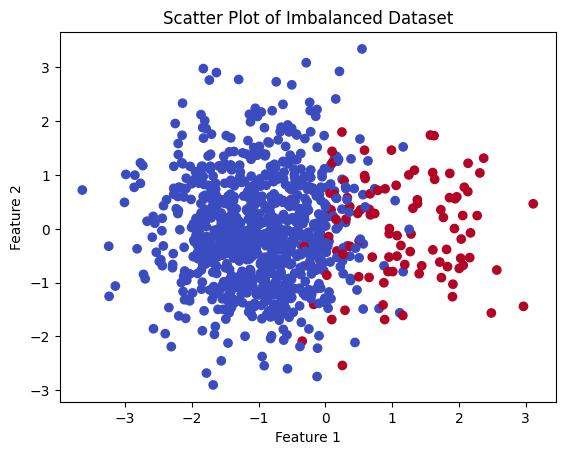

In [31]:
import matplotlib.pyplot as plt
plt.scatter(final_df['feature1'], final_df['feature2'], c=final_df['target'], cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Imbalanced Dataset')
plt.show()

In [32]:
from imblearn.over_sampling import SMOTE

Transform the dataset using SMOTE and visualize the new dataset.

In [37]:
oversample = SMOTE()
X, y = oversample.fit_resample(final_df[['feature1', 'feature2']], final_df['target'])

In [38]:
X.shape, y.shape

((1798, 2), (1798,))

In [39]:
len(y[y==0])

899

In [40]:
len(y[y==1])

899

In [41]:
df1 = pd.DataFrame(X, columns=['feature1', 'feature2'])
df2 = pd.DataFrame(y, columns=['target'])
oversample_df = pd.concat([df1, df2], axis=1)

Text(0, 0.5, 'Feature 2')

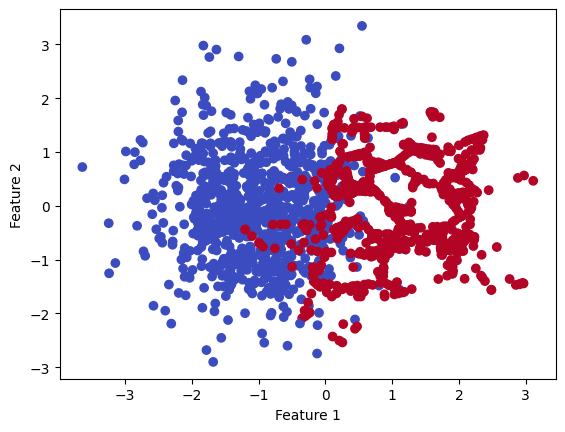

In [42]:
plt.scatter(oversample_df['feature1'], oversample_df['feature2'], c=oversample_df['target'], cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 

## Conclusion

In this notebook, we worked with a synthetic dataset with a 90/10 class imbalance (900 vs. 100 samples) and explored three techniques to address it.

**Upsampling** (`resample` with `replace=True`) duplicated minority class samples until it matched the majority size, resulting in a balanced 900/900 dataset. It is simple and keeps all original data, but the model sees the same minority samples repeatedly, which can cause overfitting.

**Downsampling** (`resample` with `replace=False`) reduced the majority class to match the minority size, giving a balanced 100/100 dataset. It is fast, but you discard 800 majority samples — potentially throwing away useful signal.

**SMOTE** generated *synthetic* minority samples by interpolating between existing neighbors rather than copying them, bringing class 1 from 101 to 899 samples (matching class 0). The scatter plot showed the new synthetic points filling in the minority class region naturally, giving the model more varied examples without the overfitting risk of simple upsampling.

**When to use each:**
- **Downsampling** — large dataset, majority class is well-represented enough that losing samples won't hurt.
- **Upsampling** — small dataset, quick baseline, low risk of overfitting.
- **SMOTE** — the strongest general-purpose choice; creates diverse synthetic samples and avoids data loss.

One important rule: always apply any balancing technique **only to the training set**. Applying it to the test set would distort your evaluation metrics and give a false picture of real-world performance.